# Sentimental Analysis 

In [1]:
# importing libraries 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 
import nltk 
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [3]:
data=pd.read_csv("imbd.csv")

In [4]:
data


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [5]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
data.shape

(50000, 2)

In [7]:
data.describe

<bound method NDFrame.describe of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
#data cleaning 

In [10]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(418)

In [12]:
data.drop_duplicates(inplace=True)

In [13]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [14]:
# target distribution 

In [15]:
data['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [16]:
# target variable to numeric conversion 

In [17]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})

In [18]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [19]:
# text cleaning 

In [20]:
data['review']=data['review'].str.lower()

In [21]:
# remvoing html tags

In [22]:
def remove_html(text):
    return re.sub(r'<,*?>',  ' ',text)
data['review']=data['review'].apply(remove_html)

In [23]:
data

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. <br /><br />the...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1
...,...,...
49995,i thought this movie did a down right good job...,1
49996,"bad plot, bad dialogue, bad acting, idiotic di...",0
49997,i am a catholic taught in parochial elementary...,0
49998,i'm going to have to disagree with the previou...,0


In [24]:
# in nlp - natural langauge processing , stopword and lemmitization are two types of techquines which are used to preprocess the text data 

In [25]:
#stopwords in nltk - very comman words "the","is","and","a" often nltk provides
#builtin stiopword lists for multiple lanagauges thta helps in reudcing 
#noise and improve nlp performance 
# basically nltk that are use to analyse the text data and for nlp

#lemmitization:
it converts the word to their dictionary base form (lemma) 
running - run 
dogs- dog
better-good 
unlike stemming , it priduces valid dictionary words they are acucrate 

In [26]:
#removing special characters 

In [27]:
def remove_special(text):
    return re.sub(r'[^a-zA-Z\s]', '',text)
data['review']=data['review'].apply(remove_special)

In [28]:
remove_special("i thought this mvie did a good job ")

'i thought this mvie did a good job '

In [29]:
# remove stopwords

In [30]:
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
def remove_stopwords(text):
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return " ".join(words)
data['review']=data['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# lemmiziation 

In [32]:
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer=WordNetLemmatizer()
def lemmatizer_text(text):
    words=text.split()
    words=[lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)
data['review']=data['review'].apply(lemmatizer_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [33]:
# eda

In [34]:
#dataset overview

In [35]:
print(data.shape)
print(data.info())
print(data.describe())

(49582, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49582 non-null  object
 1   sentiment  49582 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
          sentiment
count  49582.000000
mean       0.501876
std        0.500002
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000


In [36]:
#sentiment distribution 

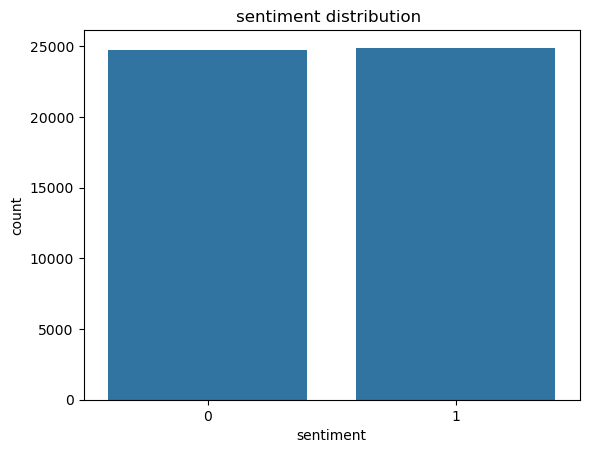

In [37]:
sns.countplot(x='sentiment',data=data)
plt.title("sentiment distribution ")
plt.show()

In [38]:
# plot the diagram for review lenght ")

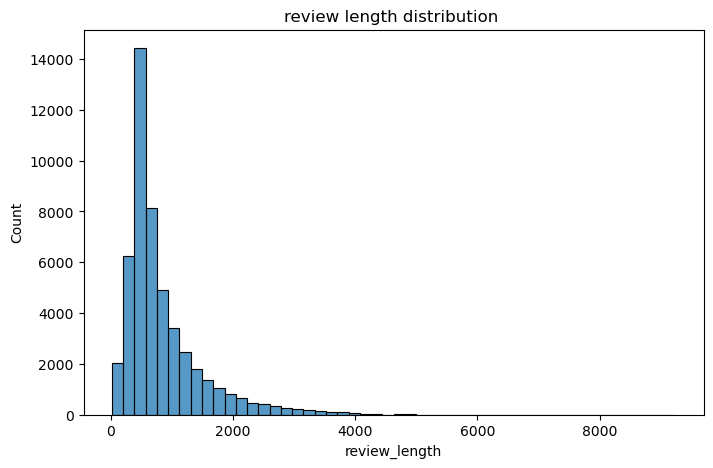

In [39]:
data['review_length']=data['review'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(data['review_length'],bins=50)
plt.title("review length distribution ")
plt.show()

In [40]:
# review length by statemnts

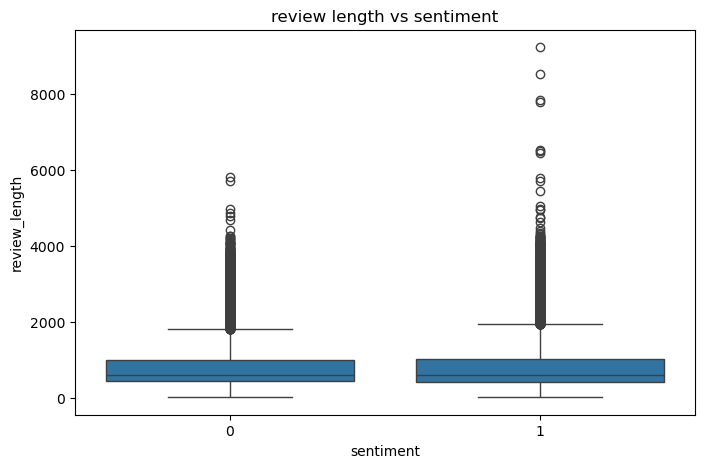

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment',y='review_length',data=data)
plt.title("review length vs sentiment")
plt.show()

In [42]:
#visuals 

In [43]:
#most frequent words 

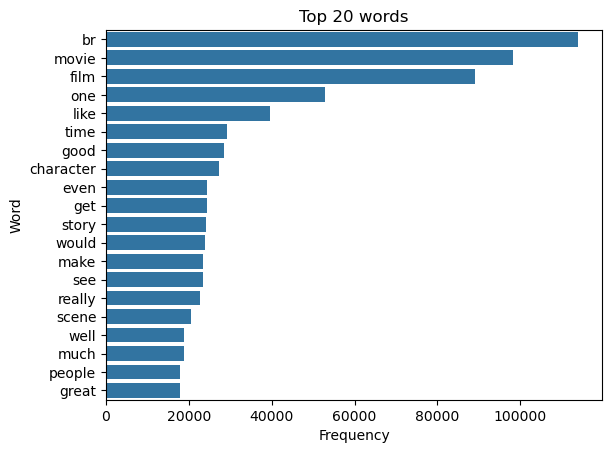

In [44]:
from collections import Counter 
all_words=" ".join(data['review']).split()
word_freq=Counter(all_words)
common_words=pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word','Frequency']
)

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words
)
plt.title("Top 20 words")
plt.show()

In [45]:
# word cloud 


In [46]:
# install a libary in python 

In [47]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


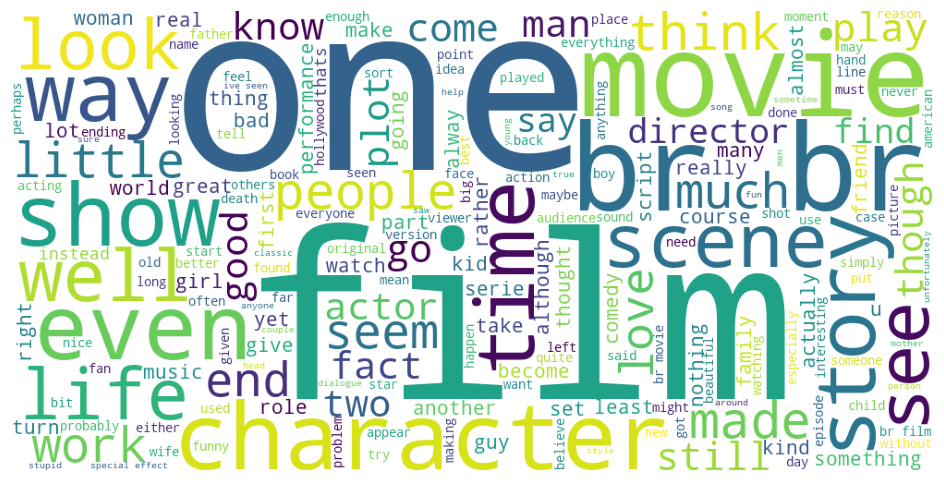

In [48]:
from wordcloud import WordCloud

text= " ".join(data['review'])
wc=WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [52]:
data

,review,sentiment,review_length
0,one reviewer mentioned watching oz episode you...,1,1134
1,wonderful little production br br filming tech...,1,658
2,thought wonderful way spend time hot summer we...,1,582
3,basically there family little boy jake think t...,0,459
4,petter matteis love time money visually stunni...,1,864
...,...,...,...
49995,thought movie right good job wasnt creative or...,1,547
49996,bad plot bad dialogue bad acting idiotic direc...,0,404
49997,catholic taught parochial elementary school nu...,0,811
49998,im going disagree previous comment side maltin...,0,819


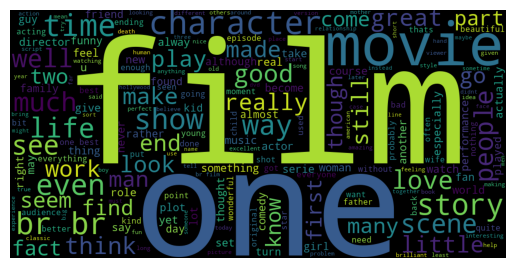

In [51]:
# positive word cloud 
positive_text=" ".join(
    data[data['sentiment']==1]['review']
)
WordCloud(
    width=1000,
    height=500
).generate(positive_text)

plt.imshow(
    WordCloud(width=1000,height=500)
    .generate(positive_text)
)
plt.axis('off')
plt.show()
    

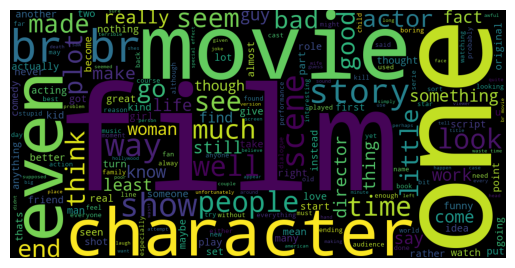

In [53]:
# negative word cloud 
negative_text=" ".join(
    data[data['sentiment']==0]['review']
)

plt.imshow(
    WordCloud(width=1000,height=500)
    .generate(negative_text)
)
plt.axis('off')
plt.show()
    

In [56]:
# machine learning 

In [ ]:
# TF-IDF VECTORIZATION 

In [ ]:
# tf-idf is used in text data or unstrucutred data to trnaform the data 

In [67]:
data=pd.read_csv("imbd.csv")

In [68]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [69]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})


In [70]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [71]:
X=data['review']
y=data['sentiment']

tfidf=TfidfVectorizer(
    max_features=5000
)
x=tfidf.fit_transform(X)

In [72]:
X

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: object

In [73]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [74]:
# train test split

In [75]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [76]:
X_test

33553    I really liked this Summerslam due to the look...
9427     Not many television shows appeal to quite as m...
199      The film quickly gets to a major chase scene w...
12447    Jane Austen would definitely approve of this o...
39489    Expectations were somewhat high for me when I ...
                               ...                        
28567    Although Casper van Dien and Michael Rooker ar...
25079    I liked this movie. I wasn't really sure what ...
18707    Yes non-Singaporean's can't see what's the big...
15200    As far as films go, this is likable enough. En...
5857     I saw Anatomy years ago -- dubbed at a friends...
Name: review, Length: 10000, dtype: object

In [77]:
y_test

33553    1
9427     1
199      0
12447    1
39489    0
        ..
28567    0
25079    1
18707    1
15200    0
5857     1
Name: sentiment, Length: 10000, dtype: int64

In [78]:
X_train

39087    That's what I kept asking myself during the ma...
30893    I did not watch the entire movie. I could not ...
45278    A touching love story reminiscent of In the M...
16398    This latter-day Fulci schlocker is a totally a...
13653    First of all, I firmly believe that Norwegian ...
                               ...                        
11284    `Shadow Magic' recaptures the joy and amazemen...
44732    I found this movie to be quite enjoyable and f...
38158    Avoid this one! It is a terrible movie. So wha...
860      This production was quite a surprise for me. I...
15795    This is a decent movie. Although little bit sh...
Name: review, Length: 40000, dtype: object

In [80]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [79]:
print(data['sentiment'].unique())

[1 0]


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [86]:
from sklearn.linear_model import LogisticRegression  # Import the model class

X = data['review']
y = data['sentiment']

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create the model instance before fitting
model = LogisticRegression()  # Define the model here
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [87]:
X=data['review']
y=data['sentiment']

tfidf =TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(X)



In [88]:
# import logitsic regression

In [89]:
from sklearn.linear_model import LogisticRegression

In [90]:
#create the model

In [91]:
lr=LogisticRegression(max_iter=1000)


In [92]:
#train the model

In [93]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [94]:
#make predictions

In [95]:
lr_pred=lr.predict(X_test)

In [96]:
lr_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

In [97]:
# accuracy 

In [98]:
# clasification model / logistic regression - confusion matrix

In [99]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test,lr_pred))

Accuracy: 0.8948


In [ ]:
# classification report

In [100]:
from sklearn.metrics import classification_report
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



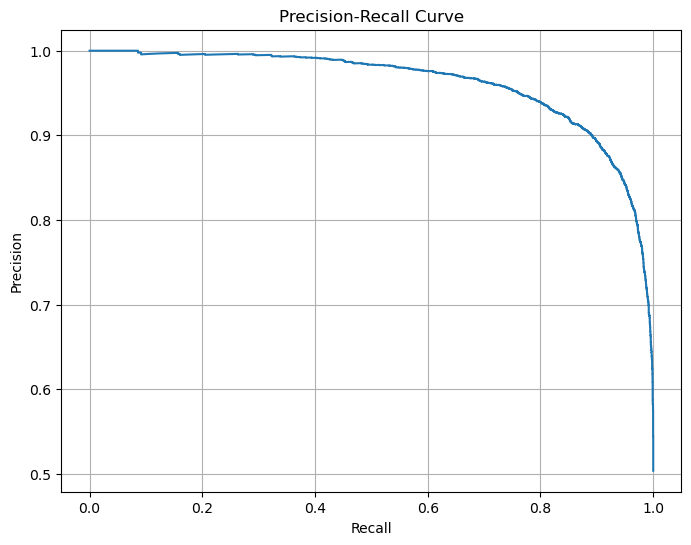

In [112]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [101]:
# confusion matrix

In [114]:
# precision meams that the values which we preducted out of them hoe many are actually posiitve 
#precision = TP/TP+FP
# recall: out of the actual posiitve reviews how many did the model find 
#recall=tp/tp+fn
# a stratight line in preciison means the model is good
# preciison should always be less

In [102]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,lr_pred)
print(cm)

[[4376  585]
 [ 467 4572]]


In [103]:
# confusion matrix you have four things - false positive , false negative , true positve and true negative 
# false positve - the actual you wished is not correct but you think its correct 
#flase negative - actual is not true and you think its not true 
#true positive - actual and predicted are both correct
#true negative - one is correct other is not 

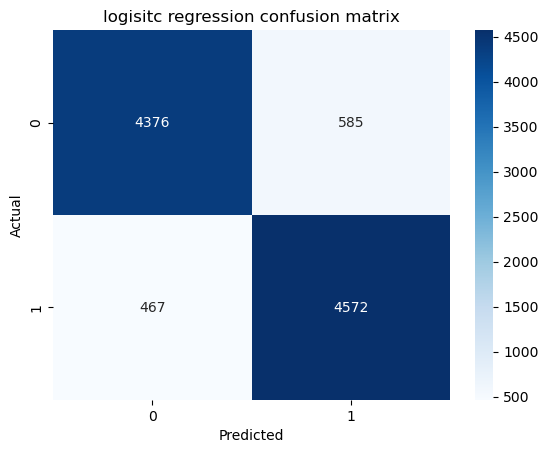

In [104]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("logisitc regression confusion matrix")
plt.show()

In [105]:
# lambda function 

In [106]:
# a lambda function is a function which is written in single line

In [107]:
# convert sentiments using lambda

In [108]:
data['sentiment']=data['sentiment'].apply(lambda x:1 if x=='positive' else 0)

In [109]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,0
1,A wonderful little production. <br /><br />The...,0
2,I thought this was a wonderful way to spend ti...,0
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",0
...,...,...
49995,I thought this movie did a down right good job...,0
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [110]:
# visulaising the precison recall curve 

In [115]:
# naive bayes

In [116]:
from sklearn.naive_bayes import MultinomialNB

In [118]:
nb=MultinomialNB()
nb.fit(X_train,y_train)
nb_pred=nb.predict(X_test)
print("\n ======naive bayes======")
print("Accuracy: ", accuracy_score(y_test,nb_pred))
print(classification_report(y_test,nb_pred))


 ======naive bayes======
Accuracy:  0.8517
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [122]:
X_test


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1176118 stored elements and shape (10000, 5000)>

In [119]:
from sklearn.ensemble import RandomForestClassifier

In [121]:
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print("\n ======Random Forest=======")
print("Accuracy:" , accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))


 ======Random Forest=======
Accuracy: 0.851
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

